# XGBoost pool model (same features as LightGBM)
Global XGBoost with same features as 05-lightgbm-pool: **VIX 5-day SMA**, **Fear & Greed change** (lag1 − lag5), month_sin, month_cos.

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.multioutput import MultiOutputRegressor
from xgboost import XGBRegressor

REPO_ROOT = Path.cwd().parent.parent
BACKEND_DIR = REPO_ROOT / "backend"
sys.path.insert(0, str(BACKEND_DIR))
sys.path.insert(0, str(Path.cwd()))

from _pool_common import (
    load_pool_data,
    build_pooled_train_stack,
    compute_metrics_averaged_over_windows,
    metrics_to_parquet,
    fetch_cnn_fear_greed_index,
    TEST_SIZE,
    FORECAST_HORIZON,
    ROLLING_STEP,
    MIN_TRAIN_STACK,
    ARTIFACTS_DIR,
    TICKERS,
)

XGB_PARAMS = dict(n_estimators=100, max_depth=4, learning_rate=0.01, random_state=42)

In [2]:
def build_feature_df(grp: pd.DataFrame):
    """Same features as LightGBM (05): VIX 5-day SMA, Fear & Greed change (lag1 - lag5), month sin/cos. Target = next 21 returns."""
    df = grp.sort_values("timestamp").copy()
    df["close"] = df["close"].astype(float)
    df["return"] = df["close"].pct_change()
    if "vix" in df.columns:
        df["vix_sma_5"] = df["vix"].astype(float).shift(1).rolling(5).mean()
    else:
        df["vix_sma_5"] = np.nan
    df["month"] = pd.to_datetime(df["timestamp"]).dt.month
    df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
    df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)
    if "fear_greed" not in df.columns:
        df["fear_greed"] = 50.0
    else:
        df["fear_greed"] = df["fear_greed"].fillna(50.0)
    df["fear_greed_lag_1"] = df["fear_greed"].shift(1)
    df["fear_greed_lag_5"] = df["fear_greed"].shift(5)
    df["fear_greed_change"] = df["fear_greed_lag_1"] - df["fear_greed_lag_5"]
    for h in range(1, FORECAST_HORIZON + 1):
        df[f"target_{h}"] = df["return"].shift(-h)
    feature_cols = ["vix_sma_5", "month_sin", "month_cos", "fear_greed_change"]
    target_cols = [f"target_{h}" for h in range(1, FORECAST_HORIZON + 1)]
    base_cols = ["timestamp", "close", "return"] + feature_cols + target_cols
    out = df[[c for c in base_cols if c in df.columns]].copy()
    return out.dropna(), feature_cols, target_cols


def train_global_xgb(stacked: pd.DataFrame, horizon: int):
    """Train one XGBoost on pooled data (all assets, rows before 60-day test window). Returns dict for predict_xgb_global."""
    pooled = build_pooled_train_stack(stacked, TEST_SIZE, MIN_TRAIN_STACK)
    if pooled.empty:
        return None
    feat_dfs = []
    for sym in pooled["symbol"].unique():
        grp = pooled[pooled["symbol"] == sym].copy()
        try:
            feat_df, feature_cols, target_cols = build_feature_df(grp)
        except Exception:
            continue
        if len(feat_df) < MIN_TRAIN_STACK + horizon:
            continue
        feat_dfs.append(feat_df)
    if not feat_dfs:
        return None
    pooled_feat = pd.concat(feat_dfs, ignore_index=True)
    X = pooled_feat[feature_cols].values.astype(np.float32)
    y = pooled_feat[target_cols].values.astype(np.float32)
    scaler = StandardScaler()
    X_s = scaler.fit_transform(X)
    xgb_multi = MultiOutputRegressor(XGBRegressor(**XGB_PARAMS))
    xgb_multi.fit(X_s, y)
    return {"model": xgb_multi, "scaler": scaler, "feature_cols": feature_cols}


def predict_xgb_global(context_df: pd.DataFrame, horizon: int, global_xgb: dict) -> list:
    """Predict 21 price steps using pre-trained global XGBoost."""
    if global_xgb is None:
        return []
    try:
        feat_df, feature_cols, _ = build_feature_df(context_df)
    except Exception:
        return []
    if len(feat_df) < 1:
        return []
    X = feat_df[feature_cols].values.astype(np.float32)
    X_s = global_xgb["scaler"].transform(X)
    last_row = X_s[-1:]
    pred_returns = global_xgb["model"].predict(last_row).ravel()
    p0 = float(context_df["close"].iloc[-1])
    prices = p0 * np.cumprod(np.concatenate([[1.0], 1.0 + pred_returns]))[1:]
    return [float(p) for p in prices[:horizon]]

In [3]:
stacked = load_pool_data(with_vix=True, with_volume=True)
symbol_start = pd.to_datetime(stacked["timestamp"]).min().strftime("%Y-%m-%d")
fear_greed_df = fetch_cnn_fear_greed_index(start_date=symbol_start)
if not fear_greed_df.empty:
    stacked["date"] = pd.to_datetime(stacked["timestamp"]).dt.normalize()
    fear_greed_df["date"] = pd.to_datetime(fear_greed_df["timestamp"]).dt.normalize()
    stacked = stacked.merge(fear_greed_df[["date", "fear_greed"]], on="date", how="left")
    stacked["fear_greed"] = stacked["fear_greed"].ffill().bfill()
    stacked = stacked.drop(columns=["date"])
print(stacked.groupby("symbol").size())
stacked.head(10)

symbol
AAPL     1256
AMZN     1256
GOOGL    1256
JNJ      1256
JPM      1256
MSFT     1256
NVDA     1256
SPY      1256
WMT      1256
XOM      1256
dtype: int64


,timestamp,symbol,close,volume,vix,fear_greed
0,2021-03-09,AAPL,121.089996,129525800,24.030001,43.360000
1,2021-03-10,AAPL,119.980003,111943300,22.559999,45.560000
2,2021-03-11,AAPL,121.959999,103026500,21.910000,50.480000
3,2021-03-12,AAPL,121.029999,88105100,20.690001,53.720000
4,2021-03-15,AAPL,123.989998,92403800,20.030001,56.520000
5,2021-03-16,AAPL,125.570000,115227900,19.790001,54.800000
6,2021-03-17,AAPL,124.760002,111932600,19.230000,57.866667
7,2021-03-18,AAPL,120.529999,121229700,21.580000,52.333333
8,2021-03-19,AAPL,119.989998,185549500,20.950001,50.833333
9,2021-03-22,AAPL,123.389999,111912300,18.879999,50.700000


In [4]:
# Train once on pooled data (all assets, only rows before 60-day test window)
global_xgb = train_global_xgb(stacked, FORECAST_HORIZON)
print("Global XGBoost (LGB features) trained on", len(build_pooled_train_stack(stacked, TEST_SIZE, MIN_TRAIN_STACK)), "pooled train rows.")

Global XGBoost (LGB features) trained on 11960 pooled train rows.


In [5]:
model_name = "xgboost_lgb_feats"
all_preds = []
for sym in TICKERS:
    grp = stacked[stacked["symbol"] == sym].copy()
    if grp.empty:
        continue
    grp = grp.sort_values("timestamp").reset_index(drop=True)
    prices = grp.set_index("timestamp")["close"].astype(float).dropna()
    n = len(prices)
    if n < TEST_SIZE + MIN_TRAIN_STACK:
        continue
    split_idx = n - TEST_SIZE
    test_index = prices.index[split_idx:]
    test_values = prices.values[split_idx:]
    preds = []
    window_ix = 0
    start = 0
    while start + FORECAST_HORIZON <= TEST_SIZE:
        context_cols = ["timestamp", "close", "vix"] + [c for c in ["volume", "fear_greed"] if c in grp.columns]
        context_df = grp.iloc[: split_idx + start][context_cols].copy()
        if len(context_df) < MIN_TRAIN_STACK:
            start += ROLLING_STEP
            continue
        price_list = predict_xgb_global(context_df, FORECAST_HORIZON, global_xgb)
        if not price_list or len(price_list) < FORECAST_HORIZON:
            start += ROLLING_STEP
            window_ix += 1
            continue
        for h in range(FORECAST_HORIZON):
            idx = start + h
            ts = test_index[idx]
            y_true = float(test_values[idx])
            y_pred = float(price_list[h])
            preds.append({"timestamp": ts, "y_true": y_true, "y_pred": y_pred, "window_ix": window_ix})
        window_ix += 1
        start += ROLLING_STEP
    if preds:
        pred_df = pd.DataFrame(preds)
        pred_df["symbol"] = sym
        all_preds.append(pred_df)

pred_xgb = pd.concat(all_preds, ignore_index=True) if all_preds else pd.DataFrame(
    columns=["timestamp", "y_true", "y_pred", "window_ix", "symbol"]
)
print(pred_xgb.groupby("symbol").size() if not pred_xgb.empty else "No predictions.")
pred_xgb.head()

symbol
AAPL     126
AMZN     126
GOOGL    126
JNJ      126
JPM      126
MSFT     126
NVDA     126
SPY      126
WMT      126
XOM      126
dtype: int64


,timestamp,y_true,y_pred,window_ix,symbol
0,2025-12-10,278.779999,277.671730,0,AAPL
1,2025-12-11,278.029999,277.790232,0,AAPL
2,2025-12-12,278.279999,278.000215,0,AAPL
3,2025-12-15,274.109985,277.857911,0,AAPL
4,2025-12-16,274.609985,278.027668,0,AAPL


XGBoost feature importance (avg over 21 horizons, global model):
          feature  importance
        vix_sma_5    0.277039
fear_greed_change    0.259509
        month_sin    0.252015
        month_cos    0.211436


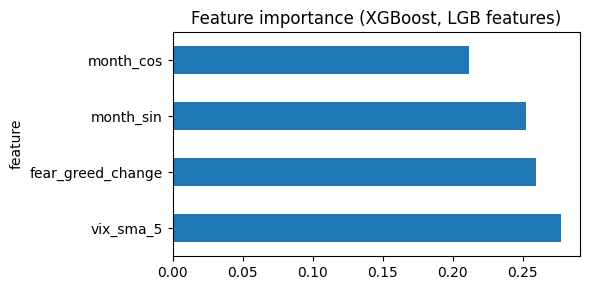

In [6]:
# Feature importance (average across 21 horizon-specific XGB estimators from global model)
import matplotlib.pyplot as plt
if global_xgb is not None:
    feature_cols = global_xgb["feature_cols"]
    xgb_multi = global_xgb["model"]
    imp = np.mean([est.feature_importances_ for est in xgb_multi.estimators_], axis=0)
    fi_df = pd.DataFrame({"feature": feature_cols, "importance": imp}).sort_values("importance", ascending=False)
    print("XGBoost feature importance (avg over 21 horizons, global model):")
    print(fi_df.to_string(index=False))
    fi_df.plot(x="feature", y="importance", kind="barh", legend=False, figsize=(6, 3))
    plt.title("Feature importance (XGBoost, LGB features)")
    plt.tight_layout()
    plt.show()
else:
    print("Run the train cell first to get global_xgb.")

In [7]:
metrics_rows = []
for sym in pred_xgb["symbol"].unique():
    sub = pred_xgb[pred_xgb["symbol"] == sym]
    m = compute_metrics_averaged_over_windows(sub)
    metrics_rows.append({"model": model_name, "symbol": sym, **m})
m_overall = compute_metrics_averaged_over_windows(pred_xgb)
metrics_rows.append({"model": model_name, "symbol": "overall", **m_overall})

metrics_df = pd.DataFrame(metrics_rows)
print(metrics_df.to_string())
metrics_to_parquet(metrics_rows, ARTIFACTS_DIR / "metrics_xgboost_lgb_feats_pool.parquet")
print("Saved:", ARTIFACTS_DIR / "metrics_xgboost_lgb_feats_pool.parquet")

                model   symbol        MAE       RMSE    MAPE_%
0   xgboost_lgb_feats     AAPL  11.125888  13.410699  4.242239
1   xgboost_lgb_feats     MSFT  28.515699  32.922353  6.654914
2   xgboost_lgb_feats    GOOGL  13.220656  15.340358  4.164742
3   xgboost_lgb_feats     AMZN  13.806205  16.215277  6.354311
4   xgboost_lgb_feats      JPM  14.058893  15.563053  4.490719
5   xgboost_lgb_feats      JNJ  10.313998  11.453928  4.494194
6   xgboost_lgb_feats      WMT   4.513723   5.233408  3.674180
7   xgboost_lgb_feats      SPY   8.312477   9.762520  1.210791
8   xgboost_lgb_feats      XOM   7.032142   8.290821  5.028020
9   xgboost_lgb_feats     NVDA   5.532131   6.927974  3.023777
10  xgboost_lgb_feats  overall  11.643181  16.161614  4.333789
Saved: C:\capstone_project_unfc\model\experiments-pool\artifacts\metrics_xgboost_lgb_feats_pool.parquet
